# GammaNet recurrent channel selectivity and saliency analysis

This notebook analyses a trained `VGG16GammaNetV2` model on contour stimuli (`C`, `straight`, and `Noshape` / `no_shape`).

The goal is to:

1. Load the trained recurrent VGG16-GammaNet model.
2. Parse all stimulus filenames into a metadata table.
3. Run images through the model and store recurrent hidden states per timestep.
4. Compute channel selectivity indices for `C`, `straight`, and `no_shape` within the same layer.
5. Select category-selective channels in a chosen recurrent layer.
6. Visualize channel activation maps on top of the stimulus.
7. Compute LRP-/saliency-like input relevance maps for category evidence scores.
8. Plot temporal dynamics of the selected channels across recurrent timesteps.

Top-down or gain modulation is intentionally not included yet. The selected channels and chosen layer are stored clearly so they can be reused later for modulation experiments.

In [1]:
# ============================================================
# 1. Imports and global settings
# ============================================================

import os
import re
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torchvision import transforms

# Make plots appear in notebooks. In VS Code this sometimes still collapses output;
# therefore plotting functions below also support saving figures.
%matplotlib inline

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Reproducibility for any random choices
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cpu


In [2]:
# ============================================================
# 2. Paths
# ============================================================

# Stimulus image directory
IMAGE_DIR = Path("/home/yentl/pytorch_gammanet/Images")

# Checkpoint path
CHECKPOINT_PATH = Path("/home/yentl/pytorch_gammanet/checkpoint_epoch_40.pt")

# Project root that contains gammanet/models/vgg16_gammanet_v2.py
PROJECT_ROOT = Path("/home/yentl/pytorch_gammanet")

# Output directory for generated figures/tables
OUTPUT_DIR = Path("/home/yentl/pytorch_gammanet/analysis_outputs/recurrent_saliency_SI")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("IMAGE_DIR:", IMAGE_DIR)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

IMAGE_DIR: /home/yentl/pytorch_gammanet/Images
CHECKPOINT_PATH: /home/yentl/pytorch_gammanet/checkpoint_epoch_40.pt
OUTPUT_DIR: /home/yentl/pytorch_gammanet/analysis_outputs/recurrent_saliency_SI


In [3]:
# ============================================================
# 3. Load model
# ============================================================

# Add project root so Python can import gammanet modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from gammanet.models.vgg16_gammanet_v2 import VGG16GammaNetV2

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

# Different checkpoints sometimes store the config under slightly different keys.
# This tries the most common structure first.
if "config" in checkpoint and "model" in checkpoint["config"]:
    model_config = checkpoint["config"]["model"]
elif "model_config" in checkpoint:
    model_config = checkpoint["model_config"]
else:
    raise KeyError("Could not find model config in checkpoint. Inspect checkpoint.keys().")

model = VGG16GammaNetV2(model_config)

# Load weights. strict=False makes the notebook more robust to small naming differences.
state_dict = checkpoint.get("model_state_dict", checkpoint.get("state_dict", None))
if state_dict is None:
    raise KeyError("Could not find model_state_dict/state_dict in checkpoint.")

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))

model.to(DEVICE)
model.eval()

print("Model timesteps:", model.timesteps)
print(model)

/tmp/ipykernel_23223/1987099387.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
/home/yentl/anaconda3/envs

Missing keys: 0
Unexpected keys: 18
Model timesteps: 4
VGG16GammaNetV2(
  (block1_conv): VGG16Block(
    (layers): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (block2_conv): VGG16Block(
    (layers): Sequential(
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (block3_conv): VGG16Block(
    (layers): Sequential(
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, k

In [4]:
# ============================================================
# 4. Image preprocessing
# ============================================================

# The model was previously used with 320 x 320 inputs.
# Keep this explicit so all feature-map sizes are predictable.
INPUT_SIZE = (320, 320)

transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
])


def load_image_tensor(path, requires_grad=False):
    """Load an image as a model-ready tensor [1, 3, H, W]."""
    pil_img = Image.open(path).convert("RGB")
    tensor = transform(pil_img).unsqueeze(0).to(DEVICE)
    tensor.requires_grad_(requires_grad)
    return pil_img, tensor

In [ ]:
# ============================================================
# 5. Parse dataset filenames into a metadata dataframe
# ============================================================

# Expected filename examples:
#   C_high_BL_0_J053_024.png
#   straight_low_BL_0_J059_006.png
#   Noshape_high_013.png
#
# For contour images:
#   contour_contrast_quadrant_position_J###_id
#
# For no-shape images:
#   Noshape_contrast_id
#
# Parsed fields:
#   contour_type: C / straight / no_shape
#   contrast: high / low
#   quadrant: TL / TR / BL / BR / None
#   position: 0, 1, 2, 3
#   jitter: integer from J000, J053, ...
#   stimulus_id: final image number


def normalize_contour_label(label):
    """Map filename contour labels to consistent category names."""
    label_clean = label.strip()
    lower = label_clean.lower()

    if lower in ["c", "ccontour", "c_contour"]:
        return "C"

    if lower in ["straight", "line", "straightline", "straight_line"]:
        return "straight"

    if lower in ["noshape", "no_shape", "noise", "none", "background"]:
        return "no_shape"

    # Keep unknown labels visible instead of silently dropping them.
    return label_clean


rows = []
failed_files = []

for path in sorted(IMAGE_DIR.glob("*.png")):

    fname = path.name
    stem = path.stem
    parts = stem.split("_")

    try:
        contour_type = normalize_contour_label(parts[0])
        contrast = parts[1]

        # ----------------------------------------------------
        # Case 1: no-shape image
        # Format:
        #   Noshape_high_013
        # parts:
        #   [Noshape, high, 013]
        # ----------------------------------------------------
        if contour_type == "no_shape":

            quadrant = None
            position = None
            jitter = 0
            stimulus_id = int(parts[2])

        # ----------------------------------------------------
        # Case 2: contour image
        # Format:
        #   C_high_BL_0_J053_024
        #   straight_low_BL_0_J059_006
        # parts:
        #   [C, high, BL, 0, J053, 024]
        # ----------------------------------------------------
        else:

            quadrant = parts[2]
            position = int(parts[3])
            jitter = int(parts[4].replace("J", ""))
            stimulus_id = int(parts[5])

    except Exception as e:

        failed_files.append({
            "filename": fname,
            "parts": parts,
            "error": str(e),
        })

        print("Could not parse:", fname, "| parts:", parts, "| error:", e)
        continue

    rows.append({
        "filename": fname,
        "path": str(path),
        "contour_type": contour_type,
        "contrast": contrast,
        "quadrant": quadrant,
        "position": position,
        "jitter": jitter,
        "stimulus_id": stimulus_id,
    })


dataset_df = pd.DataFrame(rows)

print(dataset_df.head())
print()
print("Total images:", len(dataset_df))

print()
print("Counts by contour type:")
print(dataset_df["contour_type"].value_counts())

print()
print("Available jitters:")
print(sorted(dataset_df["jitter"].unique()))

print()
print("Failed files:", len(failed_files))

if len(failed_files) > 0:
    failed_df = pd.DataFrame(failed_files)
    display(failed_df)

                   filename  \
0  C_high_BL_0_J000_008.png   
1  C_high_BL_0_J001_011.png   
2  C_high_BL_0_J002_015.png   
3  C_high_BL_0_J003_012.png   
4  C_high_BL_0_J004_024.png   

                                                path contour_type contrast  \
0  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   
1  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   
2  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   
3  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   
4  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   

  quadrant  position  jitter  stimulus_id  
0       BL         0       0            8  
1       BL         0       1           11  
2       BL         0       2           15  
3       BL         0       3           12  
4       BL         0       4           24  

Total images: 242

Counts by contour type:
contour_type
straight    122
C      

In [6]:
# ============================================================
# 6. Helper functions for hidden states and temporal states
# ============================================================

RECURRENT_LAYERS = ["h0_exc", "h1_exc", "h2_exc", "h3_exc", "h4_exc"]


def reset_and_forward(model, img_tensor):
    """Run one image through the model after resetting recurrent states."""
    model.reset_hidden_states()
    output = model(img_tensor)
    return output


def get_final_state(model, layer_name):
    """Return final hidden state from a named recurrent layer."""
    state = getattr(model, layer_name, None)
    if state is None:
        raise ValueError(f"Layer {layer_name} does not exist or is None after forward pass.")
    return state


def get_temporal_states(model, layer_name):
    """Return list of hidden states across timesteps for a layer."""
    if not hasattr(model, "temporal_activity"):
        raise ValueError("model.temporal_activity does not exist. Run a forward pass first.")
    if layer_name not in model.temporal_activity:
        raise ValueError(f"{layer_name} not found in temporal_activity. Available: {model.temporal_activity.keys()}")
    return model.temporal_activity[layer_name]


def global_channel_response(state):
    """
    Convert a hidden state [B, C, H, W] to one response per channel [C].
    This averages over batch and spatial dimensions.
    """
    return state.detach().mean(dim=(0, 2, 3)).cpu().numpy()


def spatial_channel_map(state, channel):
    """Extract one spatial channel map [H, W] from a state [B, C, H, W]."""
    return state.detach().cpu()[0, int(channel)].numpy()


def normalize_for_plot(x, eps=1e-8):
    """Min-max normalize an array for visualization only."""
    x = np.asarray(x)
    x = x - np.nanmin(x)
    x = x / (np.nanmax(x) + eps)
    return x


def resize_map_to_image(fmap, pil_img):
    """Resize a feature map to the original image size for overlay visualization."""
    fmap_t = torch.tensor(fmap, dtype=torch.float32)[None, None]
    resized = F.interpolate(
        fmap_t,
        size=pil_img.size[::-1],
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()
    return resized

In [7]:
# ============================================================
# 7. Inspect hidden state shapes for one image
# ============================================================

# This confirms how many channels and spatial positions each recurrent layer has.
example_row = dataset_df.iloc[0]
pil_img, img_tensor = load_image_tensor(example_row["path"])

with torch.no_grad():
    _ = reset_and_forward(model, img_tensor)

print("Example image:", example_row["filename"])
print("Model timesteps:", model.timesteps)

for layer in RECURRENT_LAYERS:
    state = get_final_state(model, layer)
    temporal_len = len(get_temporal_states(model, layer))
    print(f"{layer}: final state shape = {tuple(state.shape)}, stored timesteps = {temporal_len}")

Example image: C_high_BL_0_J000_008.png
Model timesteps: 4
h0_exc: final state shape = (1, 64, 320, 320), stored timesteps = 4
h1_exc: final state shape = (1, 128, 160, 160), stored timesteps = 4
h2_exc: final state shape = (1, 256, 80, 80), stored timesteps = 4
h3_exc: final state shape = (1, 512, 40, 40), stored timesteps = 4
h4_exc: final state shape = (1, 512, 20, 20), stored timesteps = 4


In [8]:
# ============================================================
# 8. Extract channel responses for all images, layers, and timesteps
# ============================================================

# This is the main feature extraction step.
# For every image, the model is run once. For each recurrent layer and timestep,
# we store one mean response per channel.
#
# Output dataframe columns:
#   filename, contour_type, contrast, quadrant, jitter, layer, timestep, responses
# where responses is a numpy vector of shape [n_channels].


def extract_recurrent_responses(model, dataset_df, contrast_filter=None, max_images=None):
    rows = []

    df = dataset_df.copy()
    if contrast_filter is not None:
        df = df[df["contrast"] == contrast_filter].copy()
    if max_images is not None:
        df = df.iloc[:max_images].copy()

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting recurrent responses"):
        pil_img, img_tensor = load_image_tensor(row["path"])

        with torch.no_grad():
            output = reset_and_forward(model, img_tensor)

        output_score = torch.sigmoid(output).mean().item()

        for layer in RECURRENT_LAYERS:
            temporal_states = get_temporal_states(model, layer)

            for t, state_t in enumerate(temporal_states):
                resp = global_channel_response(state_t)

                rows.append({
                    "filename": row["filename"],
                    "path": row["path"],
                    "contour_type": row["contour_type"],
                    "contrast": row["contrast"],
                    "quadrant": row["quadrant"],
                    "position": row["position"],
                    "jitter": row["jitter"],
                    "stimulus_id": row["stimulus_id"],
                    "layer": layer,
                    "timestep": t,
                    "output_score": output_score,
                    "responses": resp,
                })

    return pd.DataFrame(rows)


# Use high contrast by default. Change to None if you want all contrasts.
CONTRAST_FOR_ANALYSIS = "high"

response_df = extract_recurrent_responses(
    model,
    dataset_df,
    contrast_filter=CONTRAST_FOR_ANALYSIS,
    max_images=None,
)

print(response_df.head())
print("Response rows:", len(response_df))
response_df.to_pickle(OUTPUT_DIR / "response_df.pkl")

Extracting recurrent responses: 100%|██████████| 121/121 [11:55<00:00,  5.91s/it]

                   filename  \
0  C_high_BL_0_J000_008.png   
1  C_high_BL_0_J000_008.png   
2  C_high_BL_0_J000_008.png   
3  C_high_BL_0_J000_008.png   
4  C_high_BL_0_J000_008.png   

                                                path contour_type contrast  \
0  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   
1  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   
2  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   
3  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   
4  /home/yentl/pytorch_gammanet/Images/C_high_BL_...            C     high   

  quadrant  position  jitter  stimulus_id   layer  timestep  output_score  \
0       BL         0       0            8  h0_exc         0       0.07469   
1       BL         0       0            8  h0_exc         1       0.07469   
2       BL         0       0            8  h0_exc         2       0.07469   
3       BL         0       0        

In [9]:
# ============================================================
# 9. Compute mean response per category, layer, and timestep
# ============================================================

# This collapses across images within each category.
# It does NOT collapse across channels: each mean response is still a vector [channels].

mean_response = {}

for (contour_type, layer, timestep), sub in response_df.groupby(["contour_type", "layer", "timestep"]):
    data = np.stack(sub["responses"].values)  # [n_images, n_channels]
    mean_response[(contour_type, layer, timestep)] = data.mean(axis=0)

print("Available category/layer/timestep keys:", len(mean_response))
print(list(mean_response.keys())[:10])

Available category/layer/timestep keys: 40
[('C', 'h0_exc', np.int64(0)), ('C', 'h0_exc', np.int64(1)), ('C', 'h0_exc', np.int64(2)), ('C', 'h0_exc', np.int64(3)), ('C', 'h1_exc', np.int64(0)), ('C', 'h1_exc', np.int64(1)), ('C', 'h1_exc', np.int64(2)), ('C', 'h1_exc', np.int64(3)), ('C', 'h2_exc', np.int64(0)), ('C', 'h2_exc', np.int64(1))]


In [10]:
# ============================================================
# 10. Selectivity index functions
# ============================================================

# Pairwise SI is useful for comparing two categories:
#   SI(A vs B) = (R_A - R_B) / (abs(R_A) + abs(R_B) + eps)
# Positive means stronger for A, negative means stronger for B.
#
# Category-vs-rest SI is useful for selecting C, straight, and no_shape channels in one layer:
#   SI(category vs rest) = (R_category - mean(R_other_categories)) / denominator


def selectivity_index(resp_a, resp_b, eps=1e-8):
    return (resp_a - resp_b) / (np.abs(resp_a) + np.abs(resp_b) + eps)


def category_vs_rest_si(mean_response, category, layer, timestep, categories, eps=1e-8):
    resp_cat = mean_response[(category, layer, timestep)]
    other_resps = [mean_response[(c, layer, timestep)] for c in categories if c != category]
    resp_rest = np.stack(other_resps).mean(axis=0)
    return (resp_cat - resp_rest) / (np.abs(resp_cat) + np.abs(resp_rest) + eps)


CATEGORIES = [c for c in ["C", "straight", "no_shape"] if c in response_df["contour_type"].unique()]
print("Categories used:", CATEGORIES)

if len(CATEGORIES) < 2:
    raise ValueError("Need at least two categories to compute selectivity.")

Categories used: ['C', 'straight']


In [11]:
# ============================================================
# 11. Compute category-vs-rest SI for every layer and timestep
# ============================================================

si_results = {}
summary_rows = []

for layer in RECURRENT_LAYERS:
    for timestep in sorted(response_df["timestep"].unique()):
        for category in CATEGORIES:
            key = (category, layer, timestep)
            if key not in mean_response:
                continue

            si = category_vs_rest_si(mean_response, category, layer, timestep, CATEGORIES)
            si_results[key] = si

            summary_rows.append({
                "category": category,
                "layer": layer,
                "timestep": timestep,
                "n_channels": len(si),
                "mean_SI": float(np.mean(si)),
                "std_SI": float(np.std(si)),
                "max_SI": float(np.max(si)),
                "min_SI": float(np.min(si)),
                "n_SI_gt_0.05": int(np.sum(si > 0.05)),
                "n_SI_gt_0.08": int(np.sum(si > 0.08)),
                "n_SI_gt_0.10": int(np.sum(si > 0.10)),
            })

si_summary_df = pd.DataFrame(summary_rows)
si_summary_df.to_csv(OUTPUT_DIR / "si_summary_by_layer_timestep.csv", index=False)
si_summary_df.head(20)

,category,layer,timestep,n_channels,mean_SI,std_SI,max_SI,min_SI,n_SI_gt_0.05,n_SI_gt_0.08,n_SI_gt_0.10
0,C,h0_exc,0,64,0.000088,0.000354,0.001444,-0.000533,0,0,0
1,straight,h0_exc,0,64,-0.000088,0.000354,0.000533,-0.001444,0,0,0
2,C,h0_exc,1,64,0.000142,0.000321,0.001130,-0.000651,0,0,0
3,straight,h0_exc,1,64,-0.000142,0.000321,0.000651,-0.001130,0,0,0
4,C,h0_exc,2,64,0.000249,0.000633,0.002100,-0.000898,0,0,0
5,straight,h0_exc,2,64,-0.000249,0.000633,0.000898,-0.002100,0,0,0
6,C,h0_exc,3,64,0.000384,0.001292,0.003838,-0.002828,0,0,0
7,straight,h0_exc,3,64,-0.000384,0.001292,0.002828,-0.003838,0,0,0
8,C,h1_exc,0,128,0.000113,0.001896,0.006131,-0.004935,0,0,0
9,straight,h1_exc,0,128,-0.000113,0.001896,0.004935,-0.006131,0,0,0


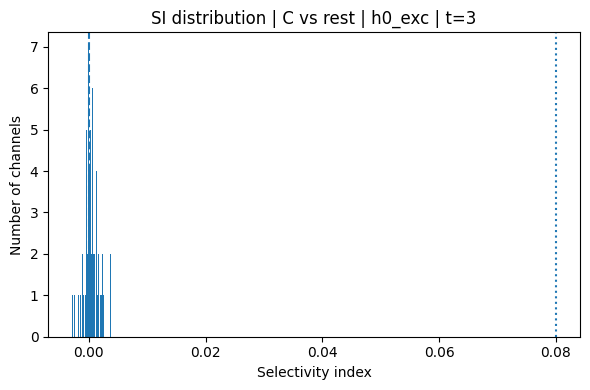

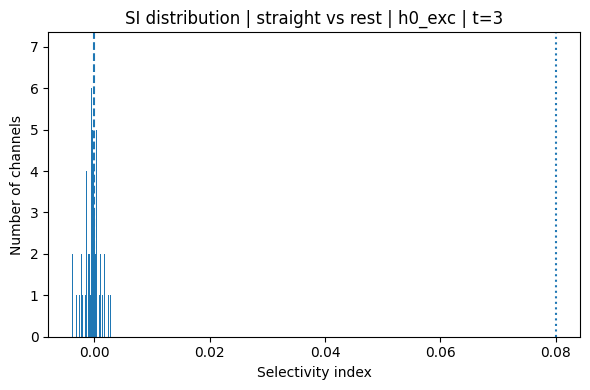

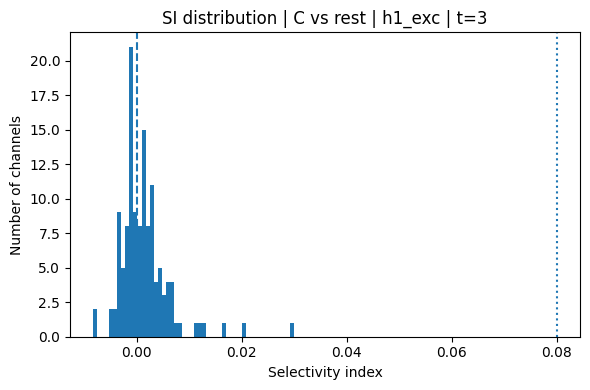

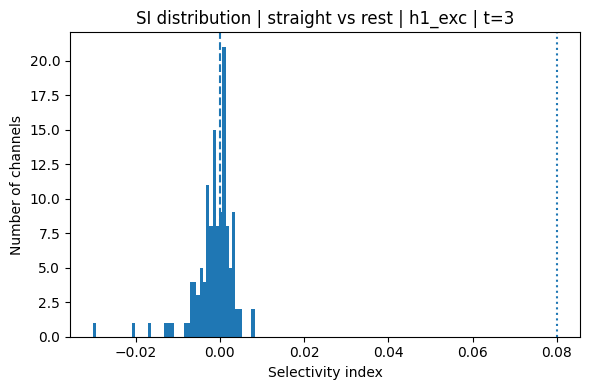

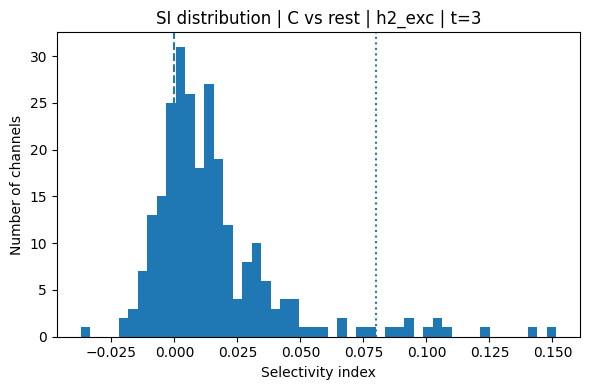

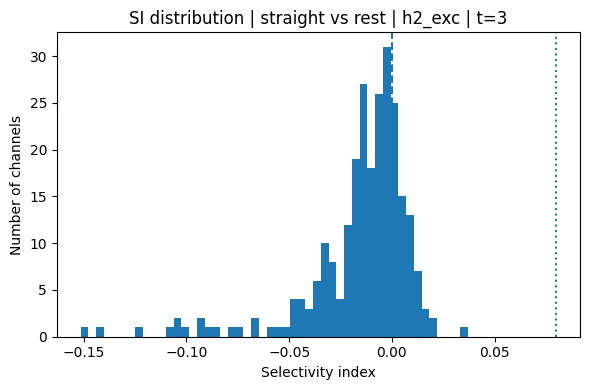

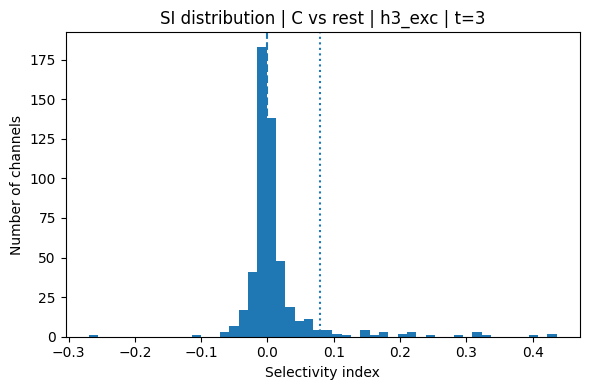

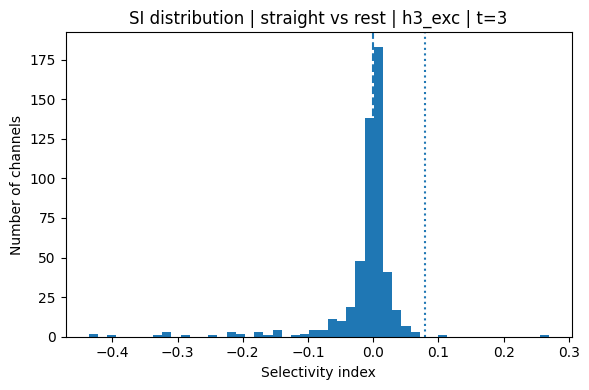

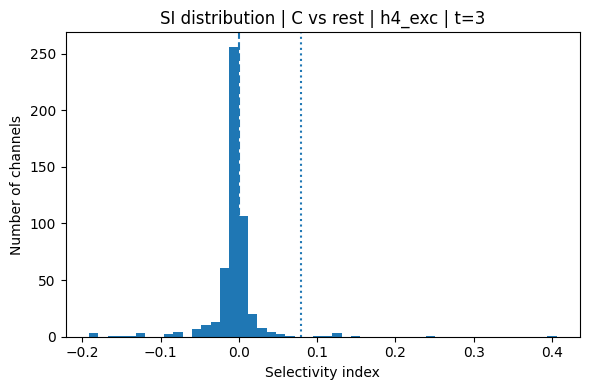

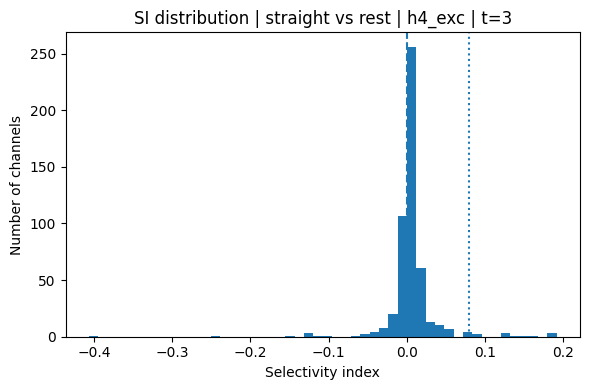

In [12]:
# ============================================================
# 12. Plot SI distributions per category/layer/timestep
# ============================================================

# These histograms show whether a layer contains channels that prefer one category over the others.
# A positive tail means channels that respond more to this category than to the other categories.

SELECT_TIMESTEP_FOR_HISTS = model.timesteps - 1  # final timestep by default

for layer in RECURRENT_LAYERS:
    for category in CATEGORIES:
        key = (category, layer, SELECT_TIMESTEP_FOR_HISTS)
        if key not in si_results:
            continue

        si = si_results[key]

        plt.figure(figsize=(6, 4))
        plt.hist(si, bins=50)
        plt.axvline(0, linestyle="--")
        plt.axvline(0.08, linestyle=":")
        plt.title(f"SI distribution | {category} vs rest | {layer} | t={SELECT_TIMESTEP_FOR_HISTS}")
        plt.xlabel("Selectivity index")
        plt.ylabel("Number of channels")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"SI_hist_{category}_{layer}_t{SELECT_TIMESTEP_FOR_HISTS}.png", dpi=150)
        plt.show()

In [ ]:
# # ============================================================
# # 13. Choose one analysis layer and select category-specific channels
# # ============================================================

# # Important:
# # You said you want to stay in the same layer for selection, visualization,
# # later modulation, and reading the output/evidence.
# #
# # Choose that layer here. You can set this to "h4_exc" if you want to focus
# # on the deepest recurrent layer, or "h3_exc" if it separates C better.

# ANALYSIS_LAYER = "h3_exc"   # change to "h3_exc" if desired
# ANALYSIS_TIMESTEP = model.timesteps - 1  # final recurrent timestep
# TOP_K_CHANNELS = 10
# SI_THRESHOLD = 0.08

# selected_channels = {}
# selected_channel_rows = []

# for category in CATEGORIES:
#     key = (category, ANALYSIS_LAYER, ANALYSIS_TIMESTEP)
#     if key not in si_results:
#         print("Missing SI for", key)
#         continue

#     si = si_results[key]
#     ranked = np.argsort(si)[::-1]  # highest category-vs-rest SI first
#     top_channels = ranked[:TOP_K_CHANNELS]
#     threshold_channels = np.where(si > SI_THRESHOLD)[0]

#     selected_channels[category] = list(map(int, top_channels))

#     for rank, ch in enumerate(top_channels, start=1):
#         selected_channel_rows.append({
#             "category": category,
#             "layer": ANALYSIS_LAYER,
#             "timestep": ANALYSIS_TIMESTEP,
#             "rank": rank,
#             "channel": int(ch),
#             "SI_category_vs_rest": float(si[ch]),
#             "passes_threshold": bool(ch in threshold_channels),
#         })

# selected_channels_df = pd.DataFrame(selected_channel_rows)
# selected_channels_df.to_csv(OUTPUT_DIR / "selected_channels.csv", index=False)

# print("Selected channels:")
# print(selected_channels)
# selected_channels_df

Selected channels:
{'C': [119, 293, 34, 325, 242, 93, 227, 183, 270, 24], 'straight': [31, 7, 503, 255, 437, 254, 97, 354, 256, 381]}


,category,layer,timestep,rank,channel,SI_category_vs_rest,passes_threshold
0,C,h3_exc,3,1,119,0.436293,True
1,C,h3_exc,3,2,293,0.423229,True
2,C,h3_exc,3,3,34,0.406862,True
3,C,h3_exc,3,4,325,0.329160,True
4,C,h3_exc,3,5,242,0.320123,True
5,C,h3_exc,3,6,93,0.315311,True
6,C,h3_exc,3,7,227,0.313242,True
7,C,h3_exc,3,8,183,0.284055,True
8,C,h3_exc,3,9,270,0.249450,True
9,C,h3_exc,3,10,24,0.219947,True


In [ ]:
# ============================================================
# 13. Choose one analysis layer and select C / straight / no_shape channels
# ============================================================

# In the previous version, channels were selected separately for each category
# using category-vs-rest SI.
#
# Here we use one signed C-vs-straight SI:
#
#   SI = (response_C - response_straight) / (response_C + response_straight)
#
# Interpretation:
#   SI >= +0.08        -> C-selective channel
#   SI <= -0.08        -> straight-selective channel
#   -0.08 < SI < 0.08  -> no_shape / neutral channel
#
# This makes no_shape an explicit readout possibility:
#   if a stimulus does not strongly activate either C-selective or straight-selective
#   populations, it can be classified as no_shape.

ANALYSIS_LAYER = "h3_exc"
ANALYSIS_TIMESTEP = model.timesteps - 1

SI_THRESHOLD = 0.08
TOP_K_CHANNELS = None   # set to an integer if you want to limit channels, e.g. 30

# ------------------------------------------------------------
# Get mean channel responses for C and straight
# ------------------------------------------------------------

c_key = ("C", ANALYSIS_LAYER, ANALYSIS_TIMESTEP)
s_key = ("straight", ANALYSIS_LAYER, ANALYSIS_TIMESTEP)

if c_key not in mean_response:
    raise ValueError(f"Missing mean response for {c_key}")

if s_key not in mean_response:
    raise ValueError(f"Missing mean response for {s_key}")

c_resp = mean_response[c_key]
s_resp = mean_response[s_key]

# ------------------------------------------------------------
# Signed C-vs-straight SI
# ------------------------------------------------------------

si_c_vs_straight = (c_resp - s_resp) / (c_resp + s_resp + 1e-8)

# ------------------------------------------------------------
# Select channels based on signed SI
# ------------------------------------------------------------

c_channels = np.where(si_c_vs_straight >= SI_THRESHOLD)[0]
straight_channels = np.where(si_c_vs_straight <= -SI_THRESHOLD)[0]
no_shape_channels = np.where(
    (si_c_vs_straight > -SI_THRESHOLD) &
    (si_c_vs_straight < SI_THRESHOLD)
)[0]

# Optional: limit the number of channels per group
# Useful if the no_shape group becomes very large.
if TOP_K_CHANNELS is not None:

    # Most positive SI values
    c_channels = c_channels[
        np.argsort(si_c_vs_straight[c_channels])[::-1]
    ][:TOP_K_CHANNELS]

    # Most negative SI values
    straight_channels = straight_channels[
        np.argsort(si_c_vs_straight[straight_channels])
    ][:TOP_K_CHANNELS]

    # Most neutral channels, closest to zero
    no_shape_channels = no_shape_channels[
        np.argsort(np.abs(si_c_vs_straight[no_shape_channels]))
    ][:TOP_K_CHANNELS]

selected_channels = {
    "C": list(map(int, c_channels)),
    "straight": list(map(int, straight_channels)),
    "no_shape": list(map(int, no_shape_channels)),
}

# ------------------------------------------------------------
# Save selected channel information
# ------------------------------------------------------------

selected_channel_rows = []

for category, channels in selected_channels.items():

    for rank, ch in enumerate(channels, start=1):

        selected_channel_rows.append({
            "category": category,
            "layer": ANALYSIS_LAYER,
            "timestep": ANALYSIS_TIMESTEP,
            "rank": rank,
            "channel": int(ch),
            "SI_C_vs_straight": float(si_c_vs_straight[ch]),
            "abs_SI": float(abs(si_c_vs_straight[ch])),
            "selection_rule": (
                "SI >= +threshold" if category == "C"
                else "SI <= -threshold" if category == "straight"
                else "between thresholds"
            ),
        })

selected_channels_df = pd.DataFrame(selected_channel_rows)

selected_channels_df.to_csv(
    OUTPUT_DIR / "selected_channels_C_straight_neutral.csv",
    index=False,
)

print("Selected channels:")
for category, channels in selected_channels.items():
    print(category, ":", len(channels), "channels")
    print(channels[:20])

display(selected_channels_df.head(20))

# ------------------------------------------------------------
# Plot signed SI distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.hist(si_c_vs_straight, bins=60)
plt.axvline(SI_THRESHOLD, linestyle=":", label="+0.08 C threshold")
plt.axvline(-SI_THRESHOLD, linestyle=":", label="-0.08 straight threshold")
plt.axvline(0, linestyle="--", label="neutral")
plt.xlabel("SI C vs straight")
plt.ylabel("Number of channels")
plt.title(f"Signed SI distribution | {ANALYSIS_LAYER} | t={ANALYSIS_TIMESTEP}")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / f"signed_SI_C_vs_straight_{ANALYSIS_LAYER}_t{ANALYSIS_TIMESTEP}.png",
    dpi=150,
)
plt.show()

In [31]:
# ============================================================
# 14. Category evidence scores from selected channels
# ============================================================

# Since GammaNet was not trained as a C/straight/no_shape classifier,
# we define category evidence using the selected SI channels.
#
# For one image:
#   C_evidence        = mean activation of C-selective channels
#   straight_evidence = mean activation of straight-selective channels
#   no_shape_evidence = mean activation of no_shape-selective channels
#
# This gives a category-like readout within the same chosen recurrent layer.


def category_evidence_from_state(state, selected_channels):
    """Compute category evidence scores from a state [B, C, H, W]."""
    evidence = {}
    for category, channels in selected_channels.items():
        if len(channels) == 0:
            evidence[category] = np.nan
            continue
        score = state[:, channels].mean().detach().cpu().item()
        evidence[category] = score
    return evidence


def run_image_and_get_evidence(model, img_tensor, layer, selected_channels, timestep=None):
    """Run image and compute evidence either from final state or from a specific timestep."""
    model.reset_hidden_states()
    with torch.no_grad():
        output = model(img_tensor)

    if timestep is None:
        state = get_final_state(model, layer)
    else:
        state = get_temporal_states(model, layer)[timestep].to(DEVICE)

    evidence = category_evidence_from_state(state, selected_channels)
    evidence["output_score_global"] = torch.sigmoid(output).mean().detach().cpu().item()
    return evidence

In [32]:
# ============================================================
# 15. Compute evidence and predicted category for all images
# ============================================================

# This creates a simple category readout based on selected channels.
# The predicted category is the category with the highest evidence score.

readout_rows = []

analysis_df = dataset_df.copy()
if CONTRAST_FOR_ANALYSIS is not None:
    analysis_df = analysis_df[analysis_df["contrast"] == CONTRAST_FOR_ANALYSIS].copy()

for _, row in tqdm(analysis_df.iterrows(), total=len(analysis_df), desc="Computing category evidence"):
    pil_img, img_tensor = load_image_tensor(row["path"])
    evidence = run_image_and_get_evidence(
        model,
        img_tensor,
        layer=ANALYSIS_LAYER,
        selected_channels=selected_channels,
        timestep=ANALYSIS_TIMESTEP,
    )

    category_scores = {c: evidence.get(c, np.nan) for c in CATEGORIES}
    predicted_category = max(category_scores, key=category_scores.get)

    readout_rows.append({
        "filename": row["filename"],
        "path": row["path"],
        "true_category": row["contour_type"],
        "contrast": row["contrast"],
        "quadrant": row["quadrant"],
        "jitter": row["jitter"],
        "predicted_category": predicted_category,
        **{f"evidence_{c}": category_scores[c] for c in CATEGORIES},
        "output_score_global": evidence["output_score_global"],
    })

readout_df = pd.DataFrame(readout_rows)
readout_df["correct_readout"] = readout_df["true_category"] == readout_df["predicted_category"]
readout_df.to_csv(OUTPUT_DIR / "category_evidence_readout.csv", index=False)
readout_df.head()

Computing category evidence: 100%|██████████| 121/121 [12:07<00:00,  6.02s/it]


,filename,path,true_category,contrast,quadrant,jitter,predicted_category,evidence_C,evidence_straight,output_score_global,correct_readout
0,C_high_BL_0_J000_008.png,/home/yentl/pytorch_gammanet/Images/C_high_BL_...,C,high,BL,0,straight,2.889243,3.655863,0.074690,False
1,C_high_BL_0_J001_011.png,/home/yentl/pytorch_gammanet/Images/C_high_BL_...,C,high,BL,1,straight,2.611040,3.122494,0.083223,False
2,C_high_BL_0_J002_015.png,/home/yentl/pytorch_gammanet/Images/C_high_BL_...,C,high,BL,2,straight,2.598701,3.292292,0.076965,False
3,C_high_BL_0_J003_012.png,/home/yentl/pytorch_gammanet/Images/C_high_BL_...,C,high,BL,3,straight,2.733723,2.927118,0.077017,False
4,C_high_BL_0_J004_024.png,/home/yentl/pytorch_gammanet/Images/C_high_BL_...,C,high,BL,4,C,3.289194,2.929645,0.076406,True


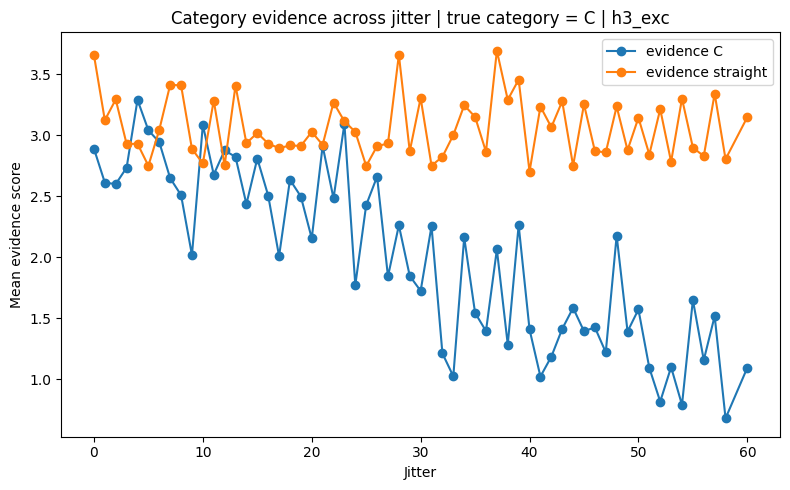

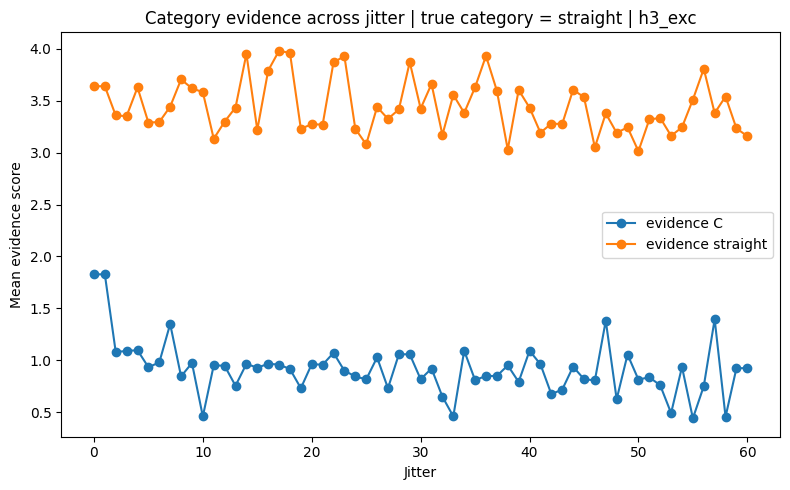

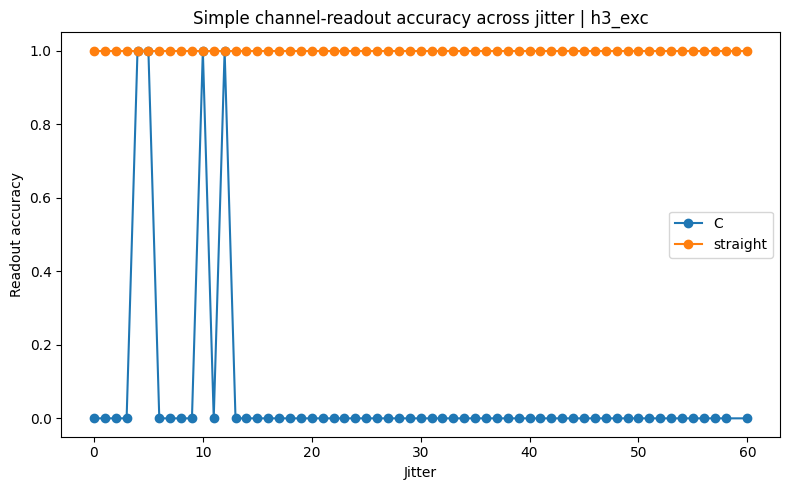

,true_category,jitter,n,accuracy,mean_evidence_C,mean_evidence_straight
0,C,0,1,0.0,2.889243,3.655863
1,C,1,1,0.0,2.611040,3.122494
2,C,2,1,0.0,2.598701,3.292292
3,C,3,1,0.0,2.733723,2.927118
4,C,4,1,1.0,3.289194,2.929645


In [33]:
# ============================================================
# 16. Plot evidence across jitter
# ============================================================

# These plots show whether category evidence changes with jitter.
# For example, C evidence may decrease as jitter increases.

mean_evidence_df = (
    readout_df
    .groupby(["true_category", "jitter"])
    .agg(
        n=("filename", "count"),
        accuracy=("correct_readout", "mean"),
        **{f"mean_evidence_{c}": (f"evidence_{c}", "mean") for c in CATEGORIES}
    )
    .reset_index()
)

mean_evidence_df.to_csv(OUTPUT_DIR / "mean_evidence_by_jitter.csv", index=False)

for true_cat in CATEGORIES:
    sub = mean_evidence_df[mean_evidence_df["true_category"] == true_cat]

    plt.figure(figsize=(8, 5))
    for c in CATEGORIES:
        plt.plot(sub["jitter"], sub[f"mean_evidence_{c}"], marker="o", label=f"evidence {c}")
    plt.title(f"Category evidence across jitter | true category = {true_cat} | {ANALYSIS_LAYER}")
    plt.xlabel("Jitter")
    plt.ylabel("Mean evidence score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"evidence_across_jitter_true_{true_cat}_{ANALYSIS_LAYER}.png", dpi=150)
    plt.show()

plt.figure(figsize=(8, 5))
for true_cat in CATEGORIES:
    sub = mean_evidence_df[mean_evidence_df["true_category"] == true_cat]
    plt.plot(sub["jitter"], sub["accuracy"], marker="o", label=true_cat)
plt.title(f"Simple channel-readout accuracy across jitter | {ANALYSIS_LAYER}")
plt.xlabel("Jitter")
plt.ylabel("Readout accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"readout_accuracy_across_jitter_{ANALYSIS_LAYER}.png", dpi=150)
plt.show()

mean_evidence_df.head()

In [35]:
# ============================================================
# 17. Activation overlay functions
# ============================================================

# These plots are forward activation maps:
#   image -> model -> selected layer/channel -> spatial activation map.
# They show where a selected channel is active in the image.


def get_example_stimulus(category, contrast="high", jitter=0, index=0):
    subset = dataset_df[
        (dataset_df["contour_type"] == category) &
        (dataset_df["contrast"] == contrast) &
        (dataset_df["jitter"] == jitter)
    ].copy()

    if len(subset) == 0:
        print(f"No image found for category={category}, contrast={contrast}, jitter={jitter}")
        return None, None, None

    row = subset.iloc[index % len(subset)]
    pil_img, img_tensor = load_image_tensor(row["path"])
    return pil_img, img_tensor, row


def plot_channel_overlay(model, pil_img, img_tensor, layer, channel, timestep=None, title="", save_path=None):
    model.reset_hidden_states()
    with torch.no_grad():
        _ = model(img_tensor)

    if timestep is None:
        state = get_final_state(model, layer)
        timestep_label = "final"
    else:
        state = get_temporal_states(model, layer)[timestep].to(DEVICE)
        timestep_label = f"t={timestep}"

    fmap = spatial_channel_map(state, channel)
    fmap_resized = resize_map_to_image(fmap, pil_img)
    fmap_norm = normalize_for_plot(fmap_resized)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(pil_img)
    ax.imshow(fmap_norm, alpha=0.5)
    ax.set_title(f"{title} {layer} channel {channel} | {timestep_label}")
    ax.axis("off")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_population_overlay(model, pil_img, img_tensor, layer, channels, timestep=None, title="", save_path=None):
    """Plot the mean activation map across a group of selected channels."""
    model.reset_hidden_states()
    with torch.no_grad():
        _ = model(img_tensor)

    if timestep is None:
        state = get_final_state(model, layer)
        timestep_label = "final"
    else:
        state = get_temporal_states(model, layer)[timestep].to(DEVICE)
        timestep_label = f"t={timestep}"

    pop_map = state[:, channels].mean(dim=1)[0].detach().cpu().numpy()
    pop_resized = resize_map_to_image(pop_map, pil_img)
    pop_norm = normalize_for_plot(pop_resized)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(pil_img)
    ax.imshow(pop_norm, alpha=0.5)
    ax.set_title(f"{title} {layer} population map | {timestep_label}")
    ax.axis("off")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

Stimulus: C_high_BL_0_J000_008.png


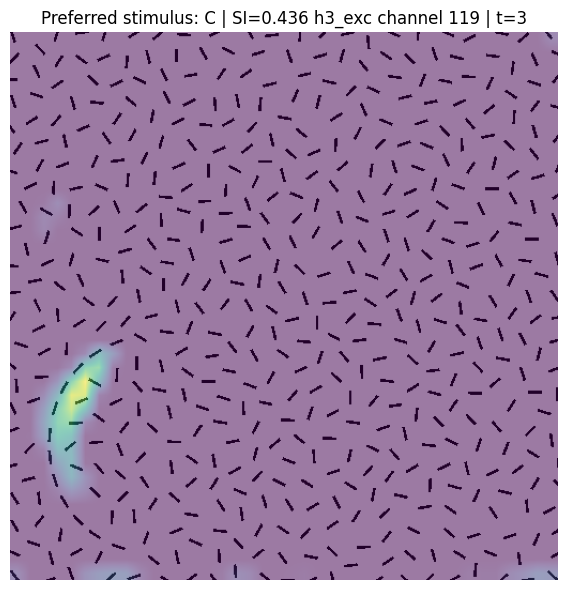

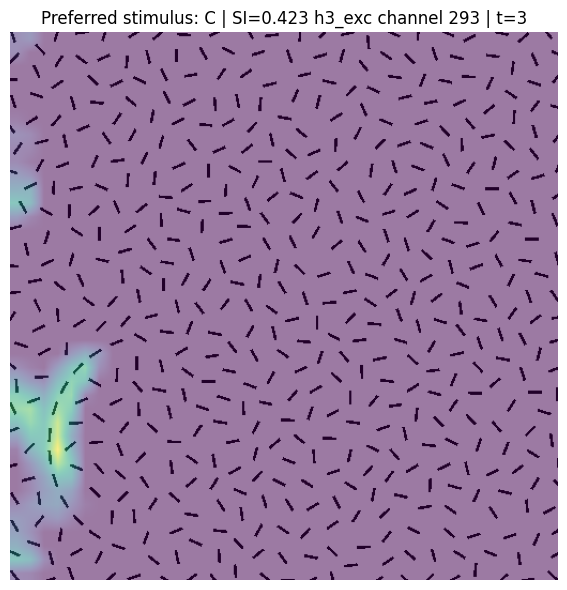

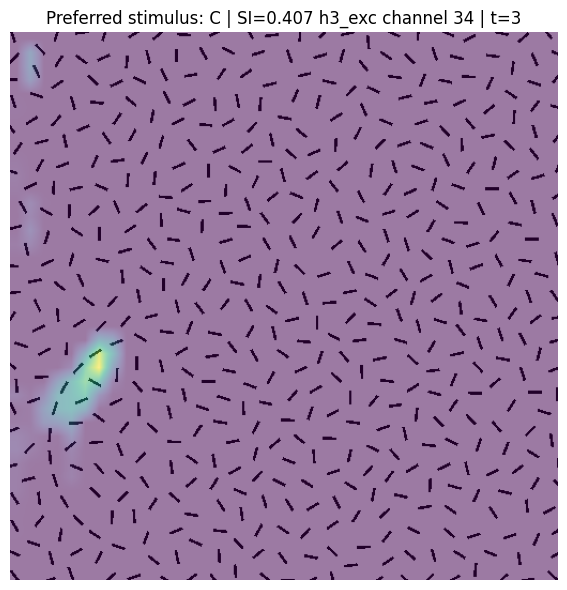

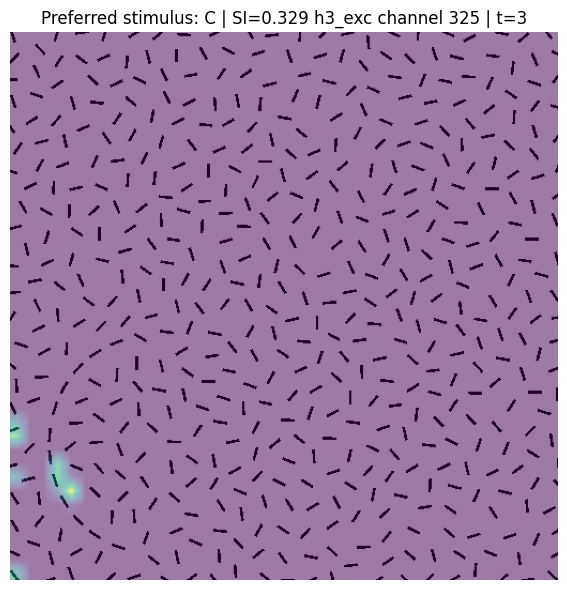

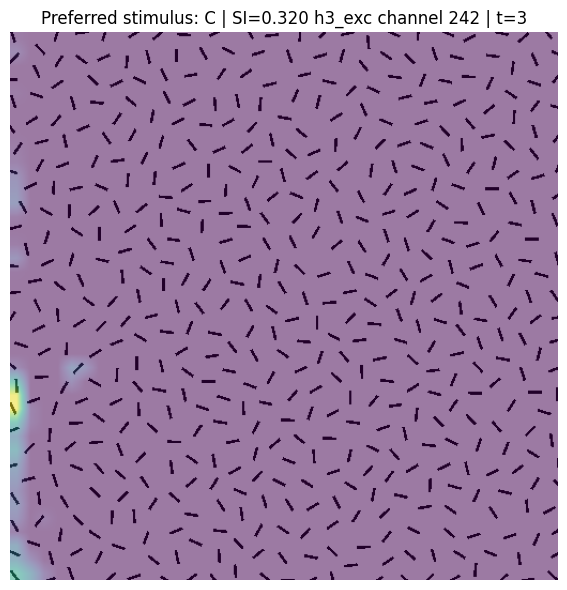

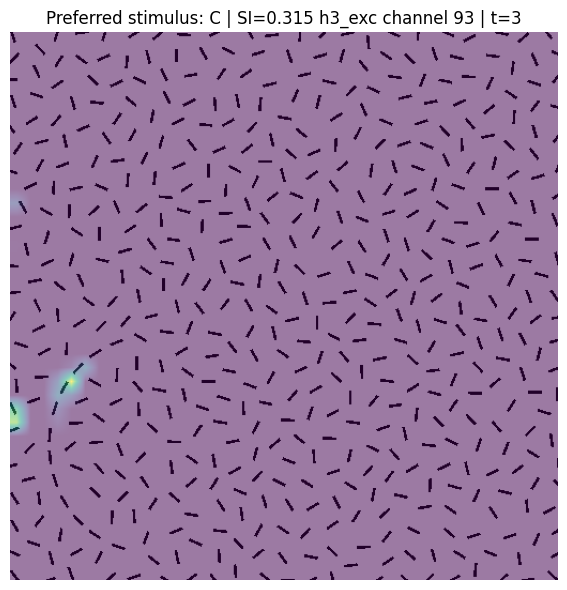

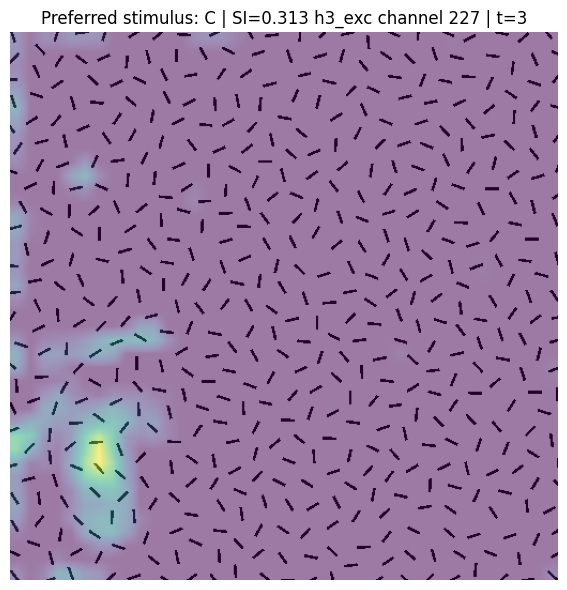

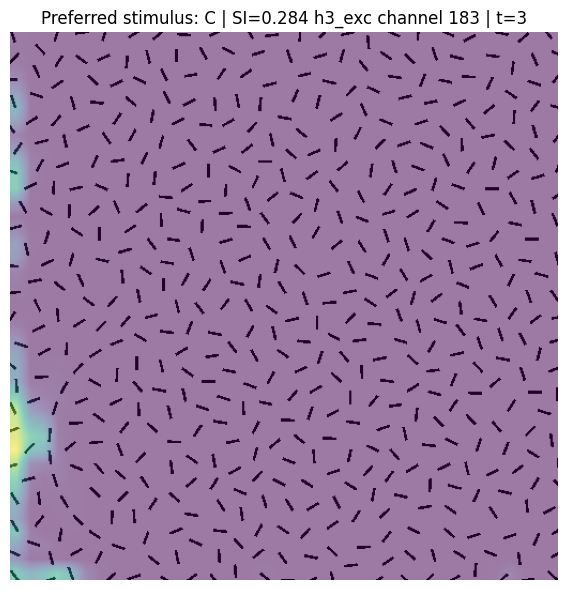

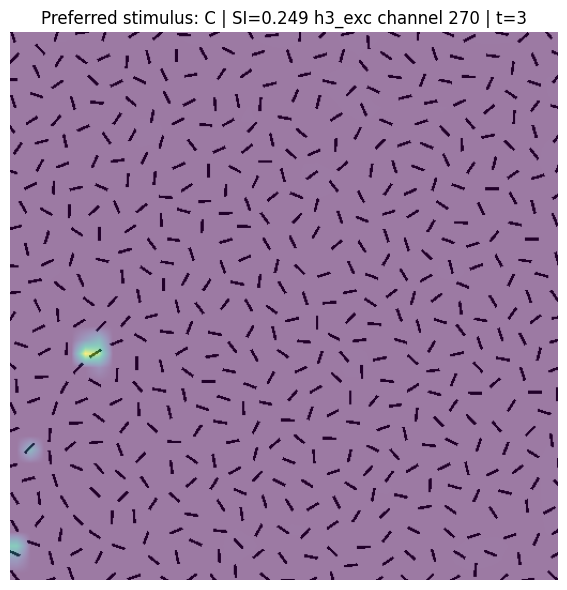

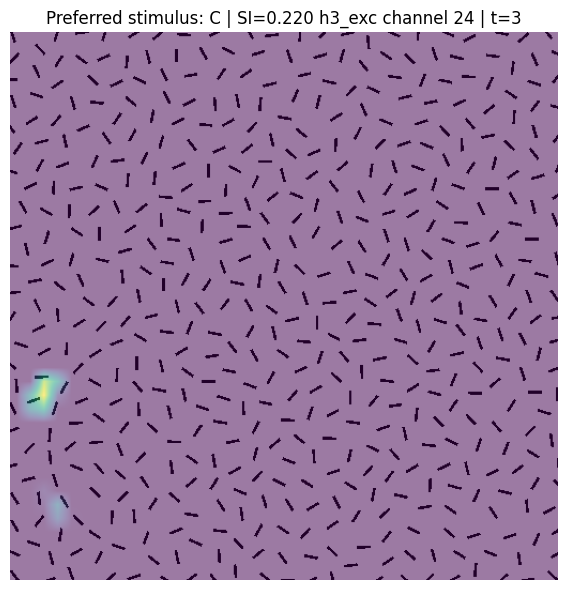

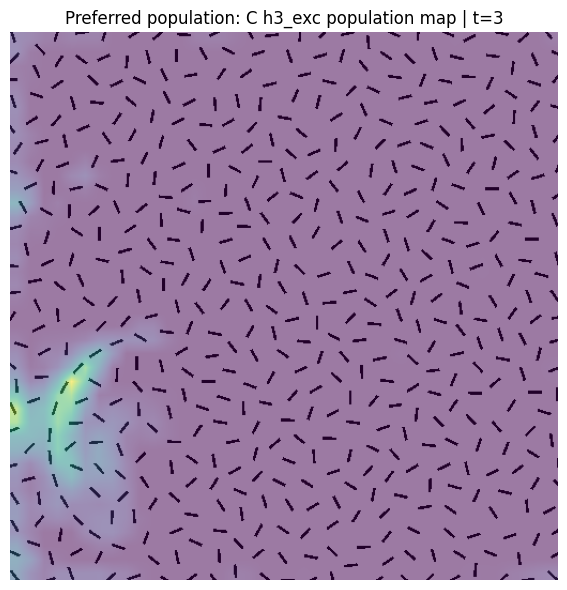

Stimulus: straight_high_BL_0_J000_003.png


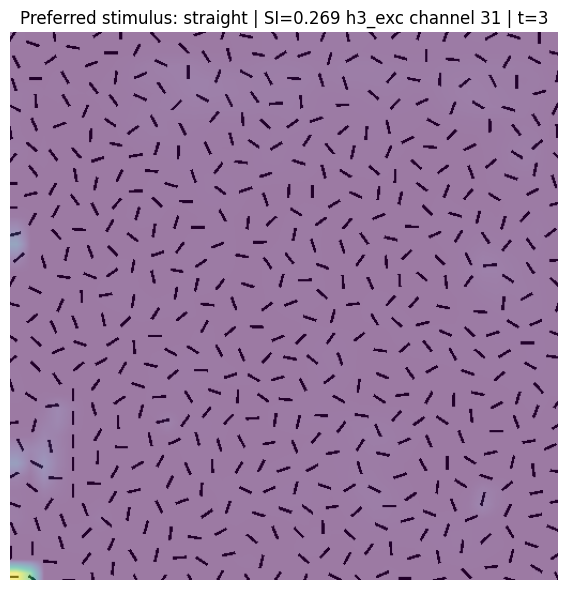

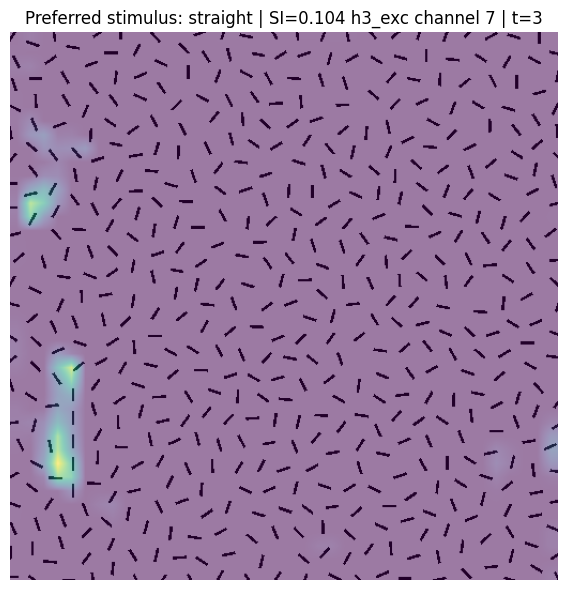

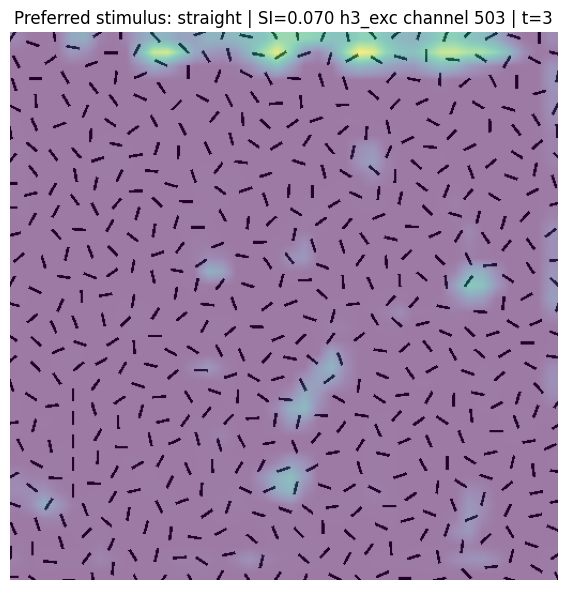

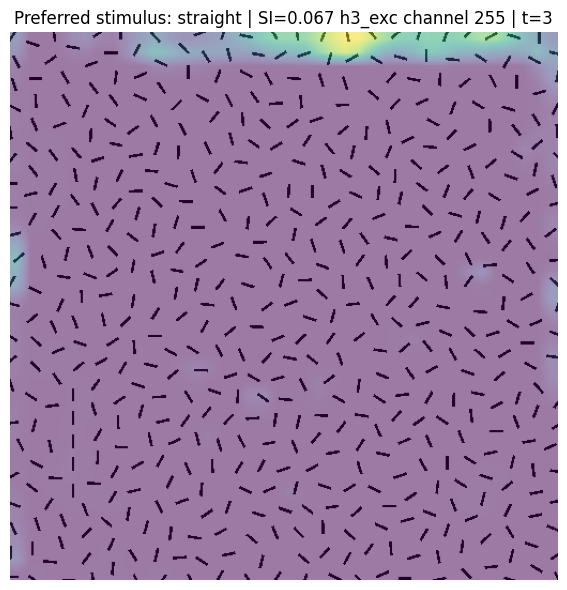

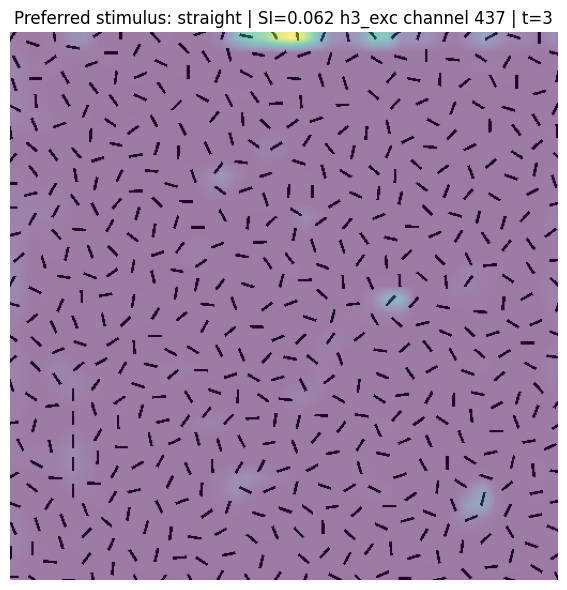

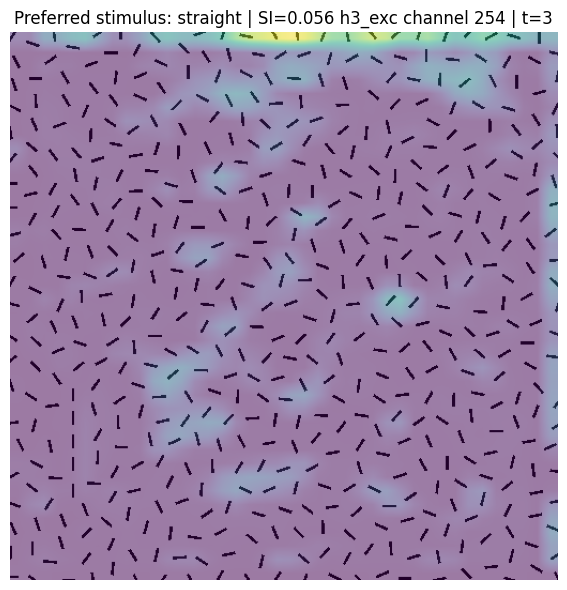

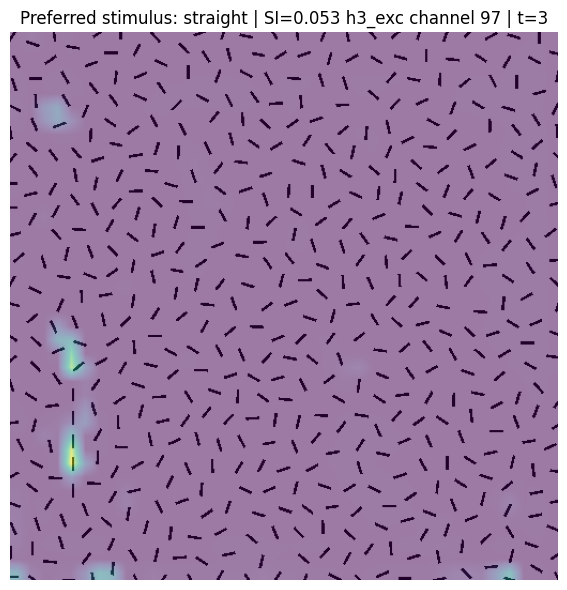

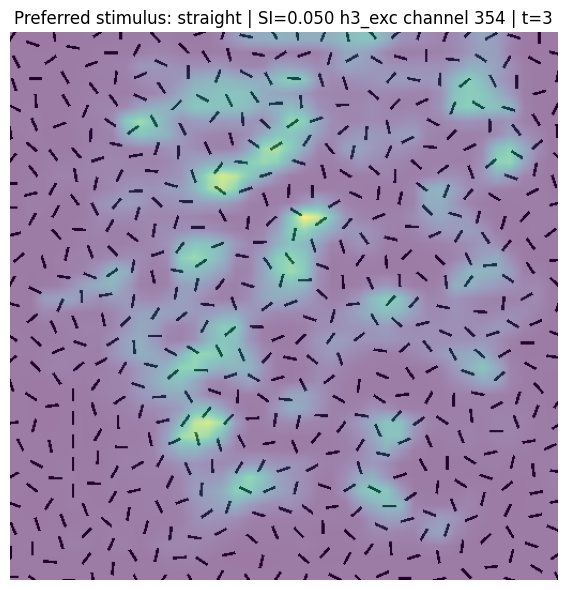

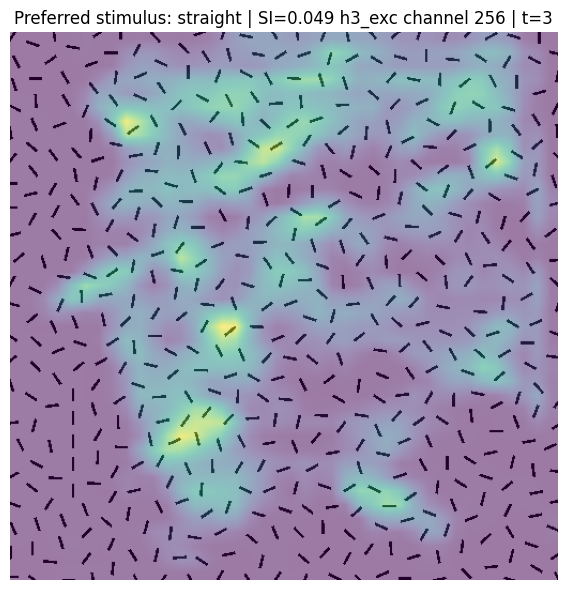

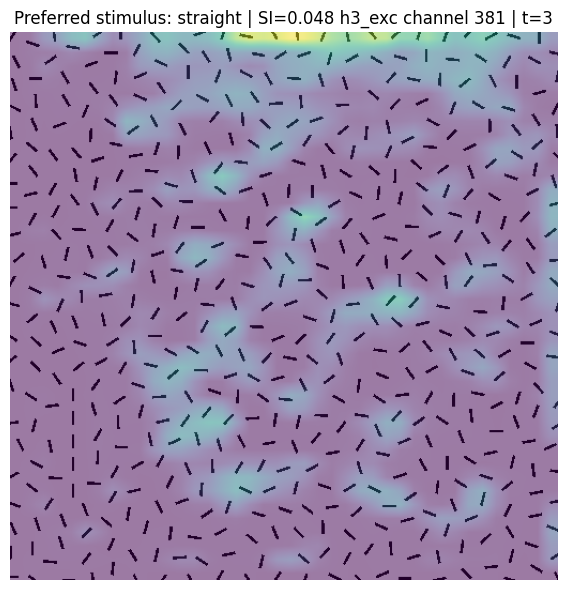

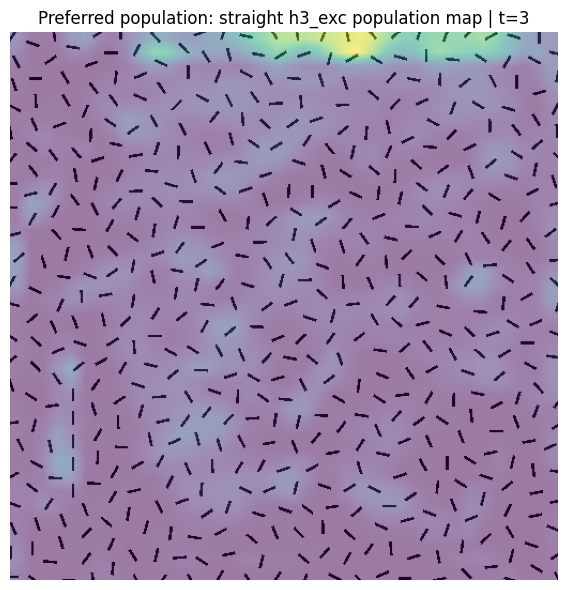

In [36]:
# ============================================================
# 18. Plot selected channel activations on preferred stimuli
# ============================================================

# For each category, plot the top selected channels on an example image from that category.
# This checks whether category-selective channels are spatially aligned with the stimulus.

PLOT_JITTER = 0
PLOT_CONTRAST = CONTRAST_FOR_ANALYSIS or "high"
N_CHANNELS_TO_PLOT = 3

for category in CATEGORIES:
    pil_img, img_tensor, row = get_example_stimulus(category, contrast=PLOT_CONTRAST, jitter=PLOT_JITTER)
    if img_tensor is None:
        continue

    print("Stimulus:", row["filename"])
    #channels = selected_channels.get(category, [])[:N_CHANNELS_TO_PLOT]
    channels = selected_channels.get(category, [])

    for ch in channels:
        si_val = si_results[(category, ANALYSIS_LAYER, ANALYSIS_TIMESTEP)][ch]
        save_path = OUTPUT_DIR / f"overlay_{category}_{ANALYSIS_LAYER}_ch{ch}_j{PLOT_JITTER}.png"
        plot_channel_overlay(
            model,
            pil_img,
            img_tensor,
            layer=ANALYSIS_LAYER,
            channel=ch,
            timestep=ANALYSIS_TIMESTEP,
            title=f"Preferred stimulus: {category} | SI={si_val:.3f}",
            save_path=save_path,
        )

    # Also plot population mean across selected channels
    if len(channels) > 0:
        save_path = OUTPUT_DIR / f"population_overlay_{category}_{ANALYSIS_LAYER}_j{PLOT_JITTER}.png"
        plot_population_overlay(
            model,
            pil_img,
            img_tensor,
            layer=ANALYSIS_LAYER,
            channels=channels,
            timestep=ANALYSIS_TIMESTEP,
            title=f"Preferred population: {category}",
            save_path=save_path,
        )

In [37]:
# ============================================================
# 19. Memory-safe LRP-like input relevance maps
# ============================================================

# This block uses the core LRP-like idea:
#   relevance ≈ activation * gradient
#
# In the original LRP.py, relevance is computed as:
#   LRP_this_layer = forward_output * forward_output.grad
#
# Here we adapt that idea to your GammaNet setting:
#   input relevance = input image * gradient of category evidence w.r.t. input
#
# This is NOT full classical LRP.
# It is a memory-safer LRP-inspired saliency method that fits your model,
# because GammaNet has recurrent hidden states rather than ImageNet class logits.

import gc

def freeze_model_parameters(model):
    """
    Disable gradients for model parameters.
    We only need gradients with respect to the input image.
    This saves a lot of memory.
    """
    old_requires_grad = {}

    for name, param in model.named_parameters():
        old_requires_grad[name] = param.requires_grad
        param.requires_grad_(False)

    return old_requires_grad


def restore_model_parameters(model, old_requires_grad):
    """Restore original requires_grad settings."""
    for name, param in model.named_parameters():
        param.requires_grad_(old_requires_grad[name])


def clear_memory():
    """Clear Python and CUDA memory as much as possible."""
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def compute_lrp_like_input_relevance(
    model,
    img_tensor,
    layer,
    category,
    selected_channels,
    use_abs=True,
):
    """
    Compute an LRP-like input relevance map for one category.

    Important:
    - This uses the FINAL hidden state of the chosen layer.
    - It does not use model.temporal_activity, because those states are detached
      and therefore cannot be used for backpropagation.
    - For temporal saliency, we need a separate custom forward pass later.

    Steps:
    1. Run image through GammaNet with gradients enabled for the input.
    2. Read the chosen recurrent layer, e.g. h3_exc or h4_exc.
    3. Define category evidence as mean activation of selected category channels.
    4. Backpropagate from this evidence score to the input image.
    5. Compute input relevance as input * gradient.
    """

    if category not in selected_channels:
        raise ValueError(f"Category {category} not found in selected_channels.")

    channels = selected_channels[category]

    if len(channels) == 0:
        raise ValueError(f"No selected channels for category {category}.")

    # Make sure previous graphs/states are removed
    clear_memory()
    model.reset_hidden_states()
    model.eval()

    # Freeze model weights: we only want gradients for the input image
    old_requires_grad = freeze_model_parameters(model)

    try:
        # Clone input and enable gradients on the input only
        x = img_tensor.detach().clone().to(DEVICE)
        x.requires_grad_(True)

        model.zero_grad(set_to_none=True)

        # No torch.no_grad() here: we need gradients for saliency
        _ = model(x)

        # Read final recurrent hidden state from the chosen layer
        state = get_final_state(model, layer)

        # Category evidence = mean activation of selected channels
        evidence_score = state[:, channels, :, :].mean()

        # Backpropagate category evidence to input image
        evidence_score.backward()

        # Input gradient: how much each input pixel influences category evidence
        grad = x.grad.detach()[0]  # [3, H, W]

        # LRP-like relevance:
        # this is where we use the LRP idea: relevance = activation * gradient
        relevance = x.detach()[0] * grad

        if use_abs:
            relevance_map = relevance.abs().mean(dim=0)
        else:
            relevance_map = relevance.mean(dim=0)

        relevance_map = relevance_map.detach().cpu().numpy()
        relevance_map = normalize_for_plot(relevance_map)

        evidence_value = float(evidence_score.detach().cpu().item())

    finally:
        # Restore model parameter settings and clean memory
        restore_model_parameters(model, old_requires_grad)

        model.zero_grad(set_to_none=True)
        model.reset_hidden_states()

        try:
            del x, state, grad, relevance, evidence_score
        except Exception:
            pass

        clear_memory()

    return relevance_map, evidence_value


def plot_lrp_like_relevance(
    model,
    pil_img,
    img_tensor,
    layer,
    category,
    selected_channels,
    title="",
    save_path=None,
    show_plot=False,
):
    """
    Plot and save an LRP-like input relevance map.

    show_plot=False is safer in WSL/Jupyter because rendering many large
    figures can crash the notebook server.
    """

    relevance_map, evidence_value = compute_lrp_like_input_relevance(
        model=model,
        img_tensor=img_tensor,
        layer=layer,
        category=category,
        selected_channels=selected_channels,
        use_abs=True,
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(pil_img)
    axes[0].set_title("Stimulus")
    axes[0].axis("off")

    axes[1].imshow(relevance_map, cmap="inferno")
    axes[1].set_title(
        f"LRP-like input relevance\n{category} evidence={evidence_value:.4f}"
    )
    axes[1].axis("off")

    axes[2].imshow(pil_img)
    axes[2].imshow(relevance_map, cmap="inferno", alpha=0.55)
    axes[2].set_title("Relevance overlay")
    axes[2].axis("off")

    fig.suptitle(
        f"{title}\nLayer={layer} | final recurrent state",
        fontsize=13
    )

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print("Saved:", save_path)

    if show_plot:
        plt.show()

    plt.close(fig)
    clear_memory()

Running safe activation-relevance map
Category: C
Stimulus: C_high_BL_0_J030_026.png
Layer: h3_exc
Channels: [119, 293, 34, 325, 242, 93, 227, 183, 270, 24]
Saved: /home/yentl/pytorch_gammanet/analysis_outputs/recurrent_saliency_SI/SAFE_activation_relevance_C_h3_exc_j30_C_high_BL_0_J030_026.png


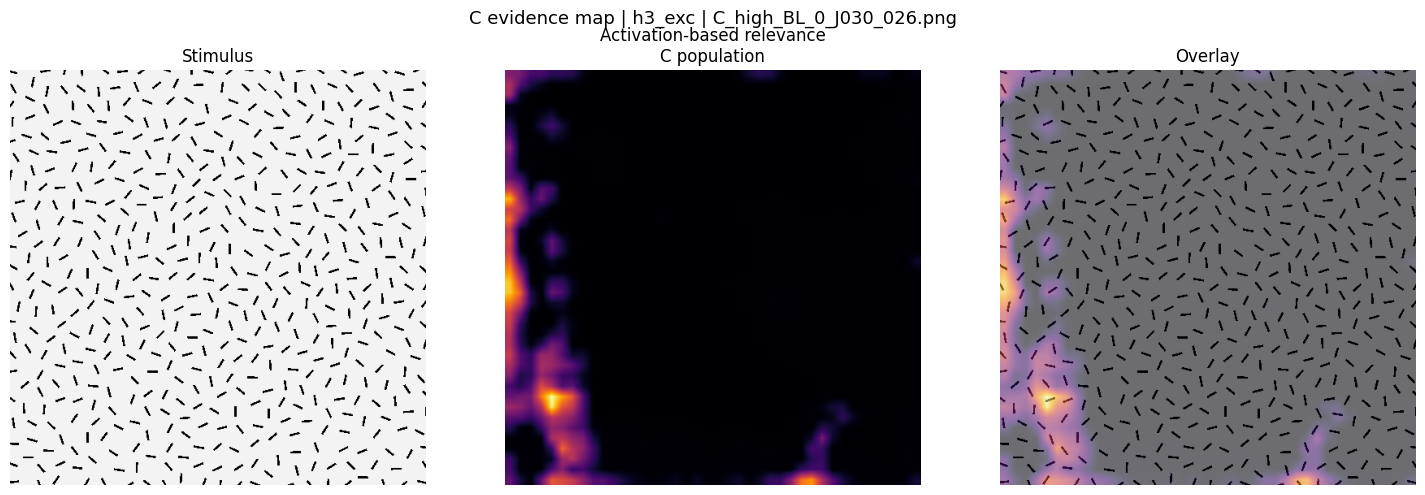

In [45]:
# ============================================================
# 20. SAFE activation-based relevance maps
# ============================================================

# This is NOT full LRP with backward propagation.
# It is a memory-safe LRP-inspired relevance approximation:
#
# Instead of:
#   relevance = input * gradient
#
# we use:
#   relevance = mean activation of selected category channels
#
# This answers:
#   Where in the selected layer is category evidence present?
#
# It is much safer for WSL because it only uses a forward pass.

SAFE_JITTER = 30
SAFE_CONTRAST = CONTRAST_FOR_ANALYSIS or "high"

# Run one category at a time
SAFE_CATEGORY_TO_RUN = "C"       # "C", "straight", or "no_shape"

pil_img, img_tensor, row = get_example_stimulus(
    SAFE_CATEGORY_TO_RUN,
    contrast=SAFE_CONTRAST,
    jitter=SAFE_JITTER,
)

if img_tensor is None:
    print("No stimulus found.")

else:
    print("Running safe activation-relevance map")
    print("Category:", SAFE_CATEGORY_TO_RUN)
    print("Stimulus:", row["filename"])
    print("Layer:", ANALYSIS_LAYER)
    print("Channels:", selected_channels[SAFE_CATEGORY_TO_RUN])

    model.reset_hidden_states()

    with torch.no_grad():
        _ = model(img_tensor)

    # --------------------------------------------------------
    # Read selected layer
    # --------------------------------------------------------
    # Example:
    #   h3_exc shape = [1, 512, H, W]
    #
    # We select only the channels that were previously classified
    # as C / straight / no_shape selective using SI.
    # --------------------------------------------------------

    state = get_final_state(model, ANALYSIS_LAYER)

    channels = selected_channels[SAFE_CATEGORY_TO_RUN]

    # --------------------------------------------------------
    # Category evidence map
    # --------------------------------------------------------
    # This is the spatial average over selected category channels.
    #
    # If this map lights up on the contour, it means:
    #   the selected category-population is active at that location.
    # --------------------------------------------------------

    relevance_map = state[:, channels, :, :].mean(dim=1)[0]
    relevance_map = relevance_map.detach().cpu().numpy()

    relevance_resized = resize_map_to_image(relevance_map, pil_img)
    relevance_norm = normalize_for_plot(relevance_resized)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(pil_img)
    axes[0].set_title("Stimulus")
    axes[0].axis("off")

    axes[1].imshow(relevance_norm, cmap="inferno")
    axes[1].set_title(
        f"Activation-based relevance\n{SAFE_CATEGORY_TO_RUN} population"
    )
    axes[1].axis("off")

    axes[2].imshow(pil_img)
    axes[2].imshow(relevance_norm, cmap="inferno", alpha=0.55)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.suptitle(
        f"{SAFE_CATEGORY_TO_RUN} evidence map | {ANALYSIS_LAYER} | {row['filename']}",
        fontsize=13
    )

    plt.tight_layout()

    save_path = OUTPUT_DIR / (
        f"SAFE_activation_relevance_{SAFE_CATEGORY_TO_RUN}_"
        f"{ANALYSIS_LAYER}_j{SAFE_JITTER}_"
        f"{row['filename'].replace('.png', '')}.png"
    )

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)

    plt.show()
    plt.close(fig)

    model.reset_hidden_states()

100%|██████████| 242/242 [1:13:56<00:00, 18.33s/it]   


,filename,true_category,contrast,quadrant,position,jitter,predicted_category,correct,C_evidence,straight_evidence
0,C_high_BL_0_J000_008.png,C,high,BL,0,0,straight,False,2.889243,3.655863
1,C_high_BL_0_J001_011.png,C,high,BL,0,1,straight,False,2.611040,3.122494
2,C_high_BL_0_J002_015.png,C,high,BL,0,2,straight,False,2.598701,3.292292
3,C_high_BL_0_J003_012.png,C,high,BL,0,3,straight,False,2.733723,2.927118
4,C_high_BL_0_J004_024.png,C,high,BL,0,4,C,True,3.289194,2.929645


predicted_category,C,straight
true_category,,
C,0.033333,0.966667
straight,0.000000,1.000000


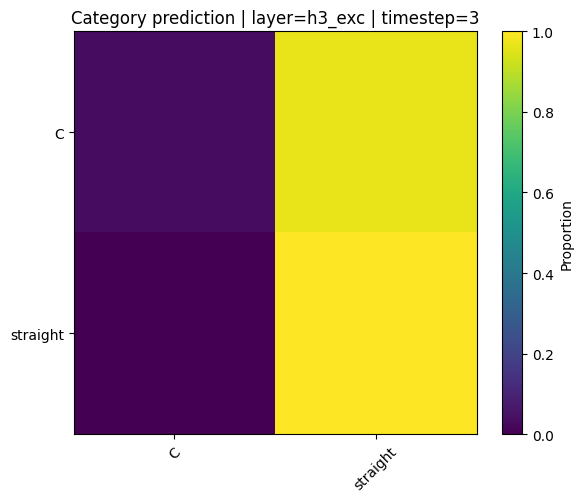

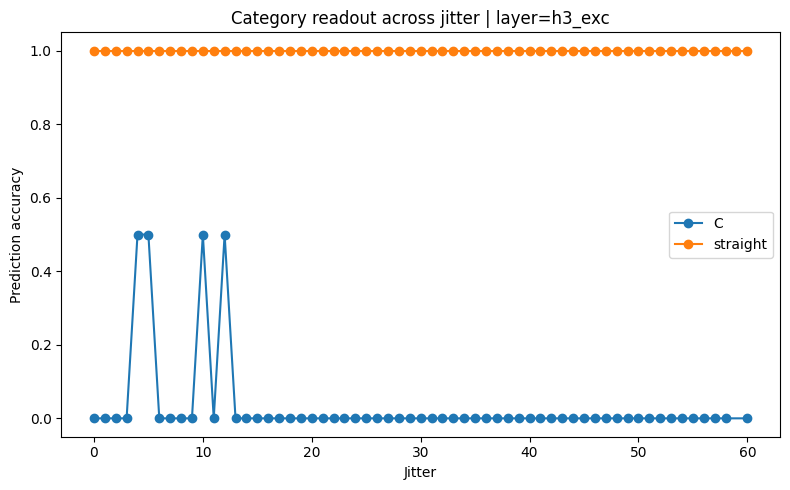

In [46]:
# ============================================================
# 21. Category evidence maps and prediction analysis
# ============================================================

# Goal:
#   For each stimulus, compute how much evidence there is for:
#       C
#       straight
#       no_shape
#
# Evidence is defined as:
#   mean activation of the selected channels for that category
#
# Prediction rule:
#   predicted category = category with the highest evidence
#
# This is not a trained classifier.
# It is a readout based on the SI-selected recurrent channel populations.


def compute_category_evidence_from_state(state, selected_channels):
    """
    Compute category evidence from one recurrent hidden state.

    Parameters
    ----------
    state : torch.Tensor
        Hidden state from one layer, e.g. h3_exc.
        Shape: [1, channels, height, width]

    selected_channels : dict
        Dictionary containing selected channels per category:
        selected_channels["C"]
        selected_channels["straight"]
        selected_channels["no_shape"]

    Returns
    -------
    evidence : dict
        Mean activation for each category-specific channel population.
    """

    evidence = {}

    for category, channels in selected_channels.items():

        if len(channels) == 0:
            evidence[category] = np.nan
            continue

        # Mean over selected channels and spatial positions
        value = state[:, channels, :, :].mean().item()

        evidence[category] = value

    return evidence


def compute_category_evidence_for_image(
    model,
    img_tensor,
    layer,
    selected_channels,
    timestep=None,
):
    """
    Run one image through the model and compute category evidence.

    If timestep is None:
        use final hidden state.
    If timestep is an integer:
        use temporal state at that timestep.
    """

    model.reset_hidden_states()

    with torch.no_grad():
        _ = model(img_tensor)

    if timestep is None:
        state = get_final_state(model, layer)
    else:
        state = get_temporal_states(model, layer)[timestep].to(DEVICE)

    evidence = compute_category_evidence_from_state(
        state,
        selected_channels,
    )

    # Winner-take-all prediction
    valid_evidence = {
        k: v for k, v in evidence.items()
        if not np.isnan(v)
    }

    predicted_category = max(
        valid_evidence,
        key=valid_evidence.get
    )

    return evidence, predicted_category


# ------------------------------------------------------------
# Run evidence readout over all images
# ------------------------------------------------------------

EVIDENCE_LAYER = ANALYSIS_LAYER
EVIDENCE_TIMESTEP = ANALYSIS_TIMESTEP  # can be None or e.g. 3

evidence_rows = []

for _, row in tqdm(dataset_df.iterrows(), total=len(dataset_df)):

    pil_img, img_tensor = load_image_tensor(row["path"])

    evidence, predicted_category = compute_category_evidence_for_image(
        model=model,
        img_tensor=img_tensor,
        layer=EVIDENCE_LAYER,
        selected_channels=selected_channels,
        timestep=EVIDENCE_TIMESTEP,
    )

    out_row = {
        "filename": row["filename"],
        "true_category": row["contour_type"],
        "contrast": row["contrast"],
        "quadrant": row["quadrant"],
        "position": row["position"],
        "jitter": row["jitter"],
        "predicted_category": predicted_category,
        "correct": predicted_category == row["contour_type"],
    }

    for category, value in evidence.items():
        out_row[f"{category}_evidence"] = value

    evidence_rows.append(out_row)


category_evidence_df = pd.DataFrame(evidence_rows)

category_evidence_df.to_csv(
    OUTPUT_DIR / "category_evidence_readout_updated.csv",
    index=False
)

display(category_evidence_df.head())


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

confusion = pd.crosstab(
    category_evidence_df["true_category"],
    category_evidence_df["predicted_category"],
    normalize="index",
)

display(confusion)

plt.figure(figsize=(6, 5))
plt.imshow(confusion.values, vmin=0, vmax=1)
plt.xticks(range(len(confusion.columns)), confusion.columns, rotation=45)
plt.yticks(range(len(confusion.index)), confusion.index)
plt.colorbar(label="Proportion")
plt.title(f"Category prediction | layer={EVIDENCE_LAYER} | timestep={EVIDENCE_TIMESTEP}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"confusion_matrix_{EVIDENCE_LAYER}.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# Accuracy across jitter
# ------------------------------------------------------------

accuracy_by_jitter = (
    category_evidence_df
    .groupby(["true_category", "jitter"])["correct"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

for category in CATEGORIES:
    sub = accuracy_by_jitter[
        accuracy_by_jitter["true_category"] == category
    ]

    if len(sub) == 0:
        continue

    plt.plot(
        sub["jitter"],
        sub["correct"],
        marker="o",
        label=category,
    )

plt.xlabel("Jitter")
plt.ylabel("Prediction accuracy")
plt.title(f"Category readout across jitter | layer={EVIDENCE_LAYER}")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"accuracy_by_jitter_{EVIDENCE_LAYER}.png", dpi=150)
plt.show()